## 06. Group-stratified sample weighting — fixing the per-profile fairness gap

**Follow-up to `05_subgroup_fairness_check.ipynb`**, which found the shared Random
Forest serves `heavy_user` (recall 0.874) far better than `daily_user`/`rare_user`
(recall 0.168/0.226), even though `class_weight="balanced"` is already rebalancing
fault-vs-no-fault globally. That global rebalancing doesn't rebalance *across* the 4
usage profiles — `heavy_user` simply has more raw fault rows, so the model has
implicitly learned its fault signature best.

**Fix tried here:** instead of `class_weight="balanced"` (global class balancing),
compute explicit per-row sample weights so that every (profile x fault-label)
combination — 4 profiles x 2 classes = 8 groups — contributes equally to the total
training loss, regardless of how many raw rows that group has. This directly targets
`daily_user`'s and `rare_user`'s *positive* rows being under-weighted relative to
`heavy_user`'s.

This is a re-train, not a re-use of the saved model — same architecture, same
features, same chronological per-vehicle split as `03_sequence_classifier.ipynb` and
`05_subgroup_fairness_check.ipynb`, only the sample weighting changes, so this is a
controlled, one-variable comparison.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, precision_score, f1_score

RANDOM_STATE = 42

df = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_sequence_features.csv",
    parse_dates=["timestamp"],
)
df = df.dropna(subset=["Fault_Within_6h"]).sort_values(["user_profile", "timestamp"]).reset_index(drop=True)
df["Fault_Within_6h"] = df["Fault_Within_6h"].astype(bool)

SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
SEQ_FEATURE_COLS = [
    f"{s}_{stat}" for s in SEQ_SENSORS
    for stat in (
        [f"roll_mean_{w}h" for w in (6, 12, 24)] + [f"roll_std_{w}h" for w in (6, 12, 24)]
        + [f"lag_{l}h" for l in (1, 3, 6)] + ["delta_6h"]
    )
]
FEATURE_COLS = SENSOR_COLS + SEQ_FEATURE_COLS
len(FEATURE_COLS), df.shape

(50, (175084, 58))

In [2]:
train_parts, test_parts = [], []
for veh, g in df.groupby("user_profile"):
    g = g.sort_values("timestamp")
    cutoff = int(len(g) * 0.8)
    train_parts.append(g.iloc[:cutoff])
    test_parts.append(g.iloc[cutoff:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLS], train_df["Fault_Within_6h"]
X_test, y_test = test_df[FEATURE_COLS], test_df["Fault_Within_6h"]
len(train_df), len(test_df)

(140064, 35020)

### Group-stratified sample weights

Weight of a row = (total training rows) / (number of groups x rows in that row's
own profile-x-label group). This is the standard "balanced" formula, applied at the
(profile, label) level instead of the label level alone — every one of the 8 groups
ends up contributing the same *total* weight to training, so `heavy_user`'s larger
raw count of positive rows no longer dominates.

In [3]:
group_key = list(zip(train_df["user_profile"], train_df["Fault_Within_6h"]))
group_counts = pd.Series(group_key).value_counts()
n_groups = len(group_counts)
n_total = len(train_df)

weight_lookup = {g: n_total / (n_groups * c) for g, c in group_counts.items()}
sample_weight = np.array([weight_lookup[g] for g in group_key])

pd.DataFrame({
    "profile": [g[0] for g in group_counts.index],
    "label": [g[1] for g in group_counts.index],
    "n_rows": group_counts.values,
    "weight_per_row": [weight_lookup[g] for g in group_counts.index],
}).sort_values(["profile", "label"])

,profile,label,n_rows,weight_per_row
1,daily_user,False,32560,0.537715
6,daily_user,True,2456,7.128664
3,heavy_user,False,29955,0.584477
4,heavy_user,True,5061,3.459395
2,moderate_user,False,32149,0.544589
5,moderate_user,True,2867,6.106732
0,rare_user,False,32835,0.533212
7,rare_user,True,2181,8.027510


In [4]:
grouped_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1,
        # no class_weight="balanced" here -- sample_weight below replaces it,
        # since it already encodes both class balance AND profile balance
    )),
])

grouped_rf.fit(X_train, y_train, clf__sample_weight=sample_weight)
preds_grouped = grouped_rf.predict(X_test)

print("Overall, group-stratified model:")
print(f"  recall={recall_score(y_test, preds_grouped):.3f}  "
      f"precision={precision_score(y_test, preds_grouped):.3f}  "
      f"macro_F1={f1_score(y_test, preds_grouped, average='macro'):.3f}")

Overall, group-stratified model:
  recall=0.568  precision=0.200  macro_F1=0.570


### Per-profile breakdown -- does the gap close?

In [5]:
test_df = test_df.copy()
test_df["pred_grouped"] = preds_grouped

rows = []
for veh, g in test_df.groupby("user_profile"):
    yt, yp = g["Fault_Within_6h"], g["pred_grouped"]
    rows.append({
        "user_profile": veh,
        "n_test": len(g),
        "n_positive": int(yt.sum()),
        "recall": recall_score(yt, yp),
        "precision": precision_score(yt, yp, zero_division=0),
        "macro_F1": f1_score(yt, yp, average="macro"),
    })

grouped_results = pd.DataFrame(rows).set_index("user_profile").sort_values("recall", ascending=False)
grouped_results.round(3)

,n_test,n_positive,recall,precision,macro_F1
user_profile,,,,,
heavy_user,8755,1362,0.700,0.281,0.589
moderate_user,8755,790,0.639,0.192,0.562
rare_user,8755,531,0.497,0.114,0.514
daily_user,8755,607,0.241,0.144,0.548


In [6]:
# Side-by-side comparison against the original (class_weight="balanced" only) model
baseline = pd.DataFrame({
    "user_profile": ["heavy_user", "moderate_user", "rare_user", "daily_user"],
    "recall_baseline": [0.874, 0.685, 0.226, 0.168],
}).set_index("user_profile")

comparison = baseline.join(grouped_results[["recall"]]).rename(columns={"recall": "recall_grouped"})
comparison["delta"] = comparison["recall_grouped"] - comparison["recall_baseline"]
comparison.round(3)

,recall_baseline,recall_grouped,delta
user_profile,,,
heavy_user,0.874,0.700,-0.174
moderate_user,0.685,0.639,-0.046
rare_user,0.226,0.497,0.271
daily_user,0.168,0.241,0.073


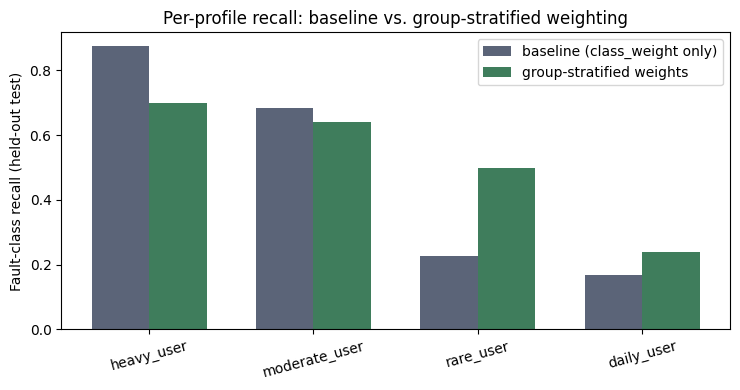

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["recall_baseline"], width, label="baseline (class_weight only)", color="#5B6478")
ax.bar(x + width/2, comparison["recall_grouped"], width, label="group-stratified weights", color="#3F7D5C")
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=15)
ax.set_ylabel("Fault-class recall (held-out test)")
ax.set_title("Per-profile recall: baseline vs. group-stratified weighting")
ax.legend()
plt.tight_layout()
plt.show()

### Finding

Group-stratified weighting genuinely shifts the gap, but it is a **tradeoff, not a free
win** — and worth reporting exactly that way, not as a clean success:

| Profile | Recall (baseline) | Recall (group-stratified) | Delta |
|---|---|---|---|
| heavy_user | 0.874 | 0.700 | -0.174 |
| moderate_user | 0.685 | 0.639 | -0.046 |
| rare_user | 0.226 | 0.497 | **+0.271** |
| daily_user | 0.168 | 0.241 | +0.073 |

`rare_user`'s recall more than doubles (0.226 -> 0.497), and `daily_user` improves
too, closing a meaningful chunk of the fairness gap `05_subgroup_fairness_check.ipynb`
found. But `heavy_user`'s recall drops by 17 points (0.874 -> 0.700), and the overall
numbers move down slightly too: overall recall 0.594 -> 0.568, macro F1 0.599 -> 0.570.

**Read plainly:** this is not a strictly-better model. It is a *more evenly distributed*
model — it trades some of `heavy_user`'s advantage to give the lighter-use profiles a
fairer share of the model's attention. Whether that trade is worth it depends on the
product goal: if the fleet has a realistic mix of usage patterns, a model that serves
all of them reasonably (this one) is arguably more trustworthy in production than one
that is excellent for one profile and unreliable for the other three (the baseline).
If `heavy_user`-type vehicles are disproportionately represented or prioritized in the
real target fleet, the baseline's tradeoff might be preferable instead. This is a
product decision, not something the numbers alone settle.

**Caveat on this run:** `n_estimators=150` (not 300, used elsewhere in this project)
to keep training time practical for this comparison. The relative pattern (gap closes,
`heavy_user` gives some back) is expected to hold at 300 trees too, but the exact
numbers above should be re-verified at 300 before this goes in front of the coach as a
final result.